In [ ]:
import numpy as np
from scipy.signal import fftconvolve

def firdes_gaussian(gain, spb, bt, ntaps):
    """Filtro gaussiano de conformacion de pulso (misma fórmula que
     GNU Radio)."""
    taps = np.empty(ntaps)
    dt = 1.0 / spb
    s = 1.0 / (np.sqrt(np.log(2.0)) / (2 * np.pi * bt))
    t0 = -0.5 * ntaps
    scale = 0.0
    for i in range(ntaps):
        t0 += 1.0
        ts = s * dt * t0
        taps[i] = np.exp(-0.5 * ts * ts)
        scale += taps[i]
    return taps / scale * gain


def gmsk_mod(bits, samples_per_symbol, bt=0.35):
    """Modulador GMSK: bits -> NRZ -> retenedor de orden cero + filtro
    gaussiano -> integracion de fase.
    Entrada: array de bits {0,1}. Salida: señal compleja en banda base a
    samples_per_symbol muestras por simbolo, con envolvente constante."""
    sps = int(samples_per_symbol)
    if sps < 2:
        raise ValueError("samples_per_symbol debe ser entero >= 2")

    ntaps = 4 * sps
    sensitivity = (np.pi / 2) / sps

    nrz = np.where(np.asarray(bits) > 0, 1.0, -1.0)

    gaussian = firdes_gaussian(1.0, sps, bt, ntaps)
    sqwave = np.ones(sps)
    taps = np.convolve(gaussian, sqwave)

    up = np.zeros(len(nrz) * sps)
    up[::sps] = nrz
    shaped = fftconvolve(up, taps, mode='same')

    phase = np.cumsum(sensitivity * shaped)
    bb = np.exp(1j * phase)

    info = {
        'sps': sps, 'bt': bt, 'ntaps': ntaps,
        'sensitivity': sensitivity,
        'n_bits': len(nrz),
        'n_muestras_bb': len(bb),
        'taps_len': len(taps),
    }
    return bb, info

In [ ]:
import numpy as np

def gmsk_demod_muestreo_fijo(iq, fs, sps, bt):
    """Demodula GMSK hasta la señal discriminada normalizada.
    Pasos: mezcla a banda base (la portadora se estima con la mediana de
    la frecuencia instantánea) -> discriminador de frecuencia ->
    normalización."""
    n = np.arange(len(iq))
    f_port = np.median(np.diff(np.unwrap(np.angle(iq))) / (2*np.pi) * fs)
    iq_bb = iq * np.exp(-1j * 2*np.pi * f_port/fs * n)

    sens = (np.pi / 2) / sps
    freq = (1.0/sens) * np.angle(iq_bb[1:] * np.conj(iq_bb[:-1]))
    frn = freq / (np.max(np.abs(freq)) + 1e-9)
    return frn, f_port

def mejor_alineamiento(rx, tx):
    """Busca el mejor alineamiento circular y polaridad entre los bits
    recibidos y los transmitidos (por búsqueda exhaustiva)."""
    tx2 = np.concatenate([tx, tx])
    mejor = None
    for pol, r in [('normal', rx), ('invertida', 1 - rx)]:
        L = min(len(r), len(tx))
        for off in range(len(tx)):
            seg = tx2[off:off+L]
            err = int(np.sum(r[:L] != seg[:L]))
            if mejor is None or err < mejor[0]:
                mejor = (err, L, off, pol)
    return mejor


def mejor_muestreo_y_alineamiento(frn, sps, tx):
    """Combina las dos busquedas anteriores: para cada offset de fase de
    muestreo, encuentra el mejor alineamiento circular, y devuelve el
    resultado global con menos errores (err, L, off_rot, pol, off_fase)."""
    spi = int(round(sps))
    mejor_global = None
    for off_fase in range(spi):
        syms = frn[off_fase::spi]
        niveles = (syms > 0).astype(int)
        err, L, off_rot, pol = mejor_alineamiento(niveles, tx)
        if mejor_global is None or err < mejor_global[0]:
            mejor_global = (err, L, off_rot, pol, off_fase)
    return mejor_global


Generando señal GMSK...
=== Modulacion (gmsk_mod) ===
  sps: 13021
  bt: 0.4
  ntaps: 52084
  sensitivity: 0.0001206356137619919
  n_bits: 128
  n_muestras_bb: 1666688
  taps_len: 65104

Buffer TX: 1666688 muestras (52084 rafagas), fc=10.709563 MHz (offset 9.56 kHz)

=== Corriendo 30 intentos ===
  intento  1/30:  BER=0.0000 (0/128 err)  portadora=9.08 kHz
  intento  2/30:  BER=0.0000 (0/128 err)  portadora=9.07 kHz
  intento  3/30:  BER=0.0000 (0/128 err)  portadora=9.19 kHz
  intento  4/30:  BER=0.0000 (0/128 err)  portadora=9.22 kHz
  intento  5/30:  BER=0.0000 (0/128 err)  portadora=8.96 kHz
  intento  6/30:  BER=0.0000 (0/128 err)  portadora=9.19 kHz
  intento  7/30:  BER=0.0000 (0/128 err)  portadora=9.18 kHz
  intento  8/30:  BER=0.0000 (0/128 err)  portadora=9.18 kHz
  intento  9/30:  BER=0.0000 (0/128 err)  portadora=9.11 kHz
  intento 10/30:  BER=0.0000 (0/128 err)  portadora=9.24 kHz
  intento 11/30:  BER=0.0000 (0/128 err)  portadora=9.01 kHz
  intento 12/30:  BER=0.0000 (0

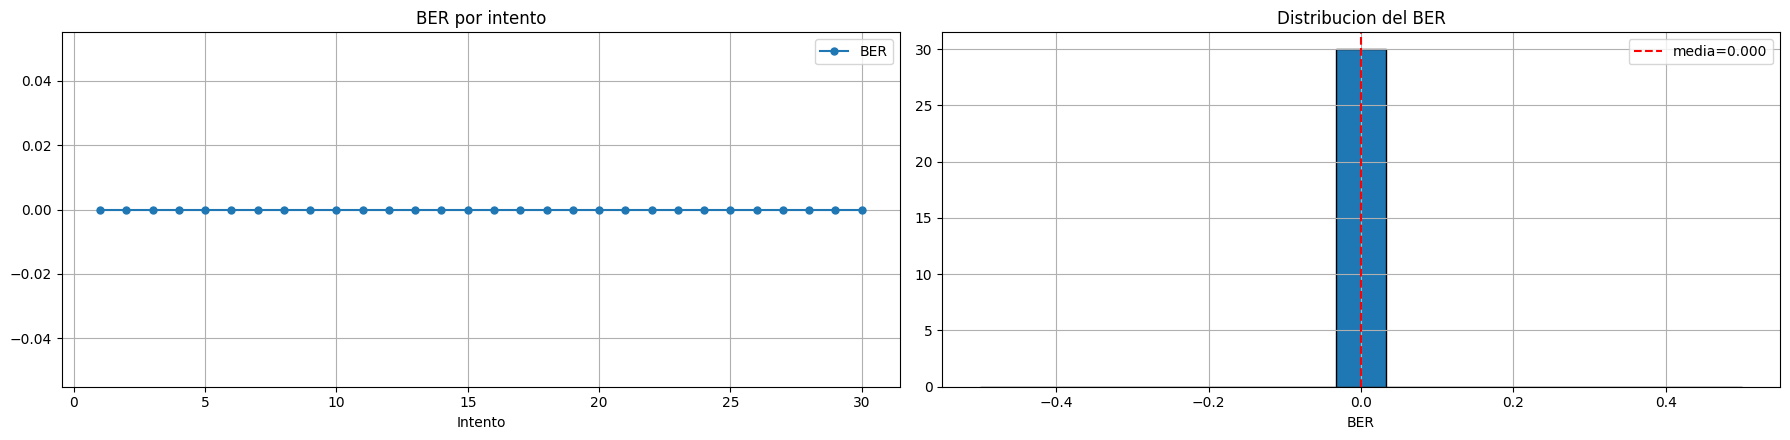

In [12]:
import socket, struct
import numpy as np
import matplotlib.pyplot as plt

HOST = '10.19.216.50'
PORT = 1003

CMD_READ_ADC = 0x03
CMD_SET_FIFO = 0x04
CMD_SET_CFG  = 0x05
CMD_TX_LOAD  = 0x06
CMD_TX_START = 0x07
CMD_TX_STOP  = 0x08

FS      = 125e6
fs_out  = 125e6 / 651     # tasa de salida del receptor (CIC+FIR)
f_lo    = 10.7e6          # LO del receptor
OFFSET  = 9.6e3            # offset de portadora sobre el LO
BT      = 0.4
N_BITS  = 128             # bits aleatorios a transmitir
AMPLITUD = 4000
TX_BURST_SAMPLES = 32     # el axis_ram_reader lee en rafagas de 32 muestras
CANT_SAMPLES_ADC = 8000

N_INTENTOS = 30
MAX_REINTENTOS_POR_INTENTO = 5   # reintentos si la portadora sale disparatada
PORTADORA_TOL = 5e3               # tolerancia: +-5 kHz respecto de OFFSET

SPS_TX = round(FS / 9600.0)    # muestras/simbolo en el DAC (125 MHz)
SPS_RX = fs_out / 9600.0       # muestras/simbolo en el receptor (~20)

PINC = round(f_lo / FS * (1 << 30))
CFG_VAL_RESET = (PINC << 1) | 0
CFG_VAL_RUN   = (PINC << 1) | 1


def send_cmd(sock, cmd, payload):
    """Envia un comando (1 byte) + payload (4 bytes) al servidor de la
    red pitaya."""
    sock.sendall(struct.pack('B', cmd)); sock.sendall(struct.pack('I', payload))


def read_ack(sock):
    return sock.recv(1)[0] == 0x01


def tx_load_and_start(sock, words):
    send_cmd(sock, CMD_TX_LOAD, len(words))
    sock.sendall(words.astype(np.int32).tobytes()); read_ack(sock)
    send_cmd(sock, CMD_TX_START, 0); read_ack(sock)


def tx_stop(sock):
    send_cmd(sock, CMD_TX_STOP, 0); read_ack(sock)


def read_adc(sock, n_samples):
    """Resetea el FIFO de captura y lee n_samples muestras complejas
    (I, Q) del ADC."""
    n_words = n_samples * 2
    send_cmd(sock, CMD_SET_FIFO, 0); read_ack(sock)
    send_cmd(sock, CMD_SET_FIFO, 1); read_ack(sock)
    send_cmd(sock, CMD_READ_ADC, n_words)
    raw = b''; total = n_words * 4
    while len(raw) < total:
        raw += sock.recv(total - len(raw))
    w = struct.unpack(f'{n_words}i', raw)
    return np.array(w[0::2], float), np.array(w[1::2], float)


# Generar bits aleatorios y modular con gmsk_mod
rng = np.random.RandomState(2024)
bits_tx = rng.randint(0, 2, N_BITS)

print("Generando señal GMSK...")
bb, mod_info = gmsk_mod(bits_tx, samples_per_symbol=SPS_TX, bt=BT)
print("=== Modulacion (gmsk_mod) ===")
for k, v in mod_info.items():
    print(f"  {k}: {v}")

# Subir a la portadora y empaquetar para el DAC
N = (len(bb) // TX_BURST_SAMPLES) * TX_BURST_SAMPLES
bb = bb[:N]
fc = f_lo + OFFSET
cycles = round(N * fc / FS); fc_adj = cycles * FS / N
t = np.arange(N) / FS
rf = np.real(bb * np.exp(1j * 2*np.pi * fc_adj * t))
rf_i16 = (rf / np.max(np.abs(rf)) * AMPLITUD).astype(np.int16)
words_tx = (rf_i16.astype(np.int32) & 0x3FFF)
print(f"\nBuffer TX: {N} muestras ({N//TX_BURST_SAMPLES} rafagas), "
      f"fc={fc_adj/1e6:.6f} MHz (offset {(fc_adj-f_lo)/1e3:.2f} kHz)")

# Conectar, cargar y arrancar el TX
sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
sock.connect((HOST, PORT))
tx_load_and_start(sock, words_tx)
send_cmd(sock, CMD_SET_CFG, CFG_VAL_RESET); read_ack(sock)
send_cmd(sock, CMD_SET_CFG, CFG_VAL_RUN);   read_ack(sock)

n_rx = CANT_SAMPLES_ADC

# N_INTENTOS capturas sucesivas
bers = []
descartes_portadora = 0

print(f"\n=== Corriendo {N_INTENTOS} intentos ===")
for intento in range(N_INTENTOS):
    for reintento in range(MAX_REINTENTOS_POR_INTENTO):
        I_bb, Q_bb = read_adc(sock, n_rx)
        iq = I_bb + 1j * Q_bb
        frn, f_port = gmsk_demod_muestreo_fijo(iq, fs_out, SPS_RX, bt=BT)

        if abs(f_port - OFFSET) <= PORTADORA_TOL:
            break
        descartes_portadora += 1
    else:
        print(f"  intento {intento+1:2d}/{N_INTENTOS}: portadora nunca coherente "
              f"tras {MAX_REINTENTOS_POR_INTENTO} reintentos, se usa igual "
              f"(f_port={f_port/1e3:.2f} kHz)")

    err, L, off_rot, pol, off_fase = mejor_muestreo_y_alineamiento(frn, SPS_RX, bits_tx)
    ber = err / L

    bers.append(ber)
    print(f"  intento {intento+1:2d}/{N_INTENTOS}:  BER={ber:.4f} "
          f"({err}/{L} err)  portadora={f_port/1e3:.2f} kHz")

tx_stop(sock); sock.close()
bers = np.array(bers)

print(f"\nCapturas descartadas por portadora incoherente (y reintentadas): {descartes_portadora}")

# Stats
print(f"\n=== Estadisticas sobre {N_INTENTOS} intentos ===")
print(f"BER     : media={bers.mean():.4f} mediana={np.median(bers):.4f} "
      f"min={bers.min():.4f} max={bers.max():.4f}")
print(f"Intentos con BER = 0    : {int(np.sum(bers==0))}/{N_INTENTOS}")
print(f"Intentos con BER < 0.05 : {int(np.sum(bers<0.05))}/{N_INTENTOS}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 4.5))

axes[0].plot(range(1, N_INTENTOS+1), bers, 'o-', ms=5, label='BER')
axes[0].set_xlabel('Intento'); axes[0].legend(); axes[0].grid(True)
axes[0].set_title('BER por intento')

axes[1].hist(bers, bins=min(15, N_INTENTOS), edgecolor='black')
axes[1].axvline(bers.mean(), color='r', ls='--', label=f'media={bers.mean():.3f}')
axes[1].set_xlabel('BER'); axes[1].set_title('Distribucion del BER'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()
